# Chromatin at replication time: Early vs Late Replicating Origins

May 3, 2024

**Goal:** Identify differences in early and late firing origins. What patterns or signals in the chromatin can be discerned at replication time. Are early replicating genes distinct from late replicating?


In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
repl_timing_file = 'datasets/computed_mnase/all_repl_timing_deconvolved.csv'
repl_timing = pd.read_csv(repl_timing_file).set_index('orf_name')
print(len(repl_timing), " genes with replication profiles")

repl_timing.head()


5250  genes with replication profiles


,timing,H_index
orf_name,,
YAL067W-A,53.314585,196
YAL067C,52.304185,194
YAL064C-A,52.809385,195
YAL064W,51.798985,193
YAL063C-A,51.798985,193


In [5]:
from src.replication_deconvolution_solver import plot_chrom_repl_timing_from_data

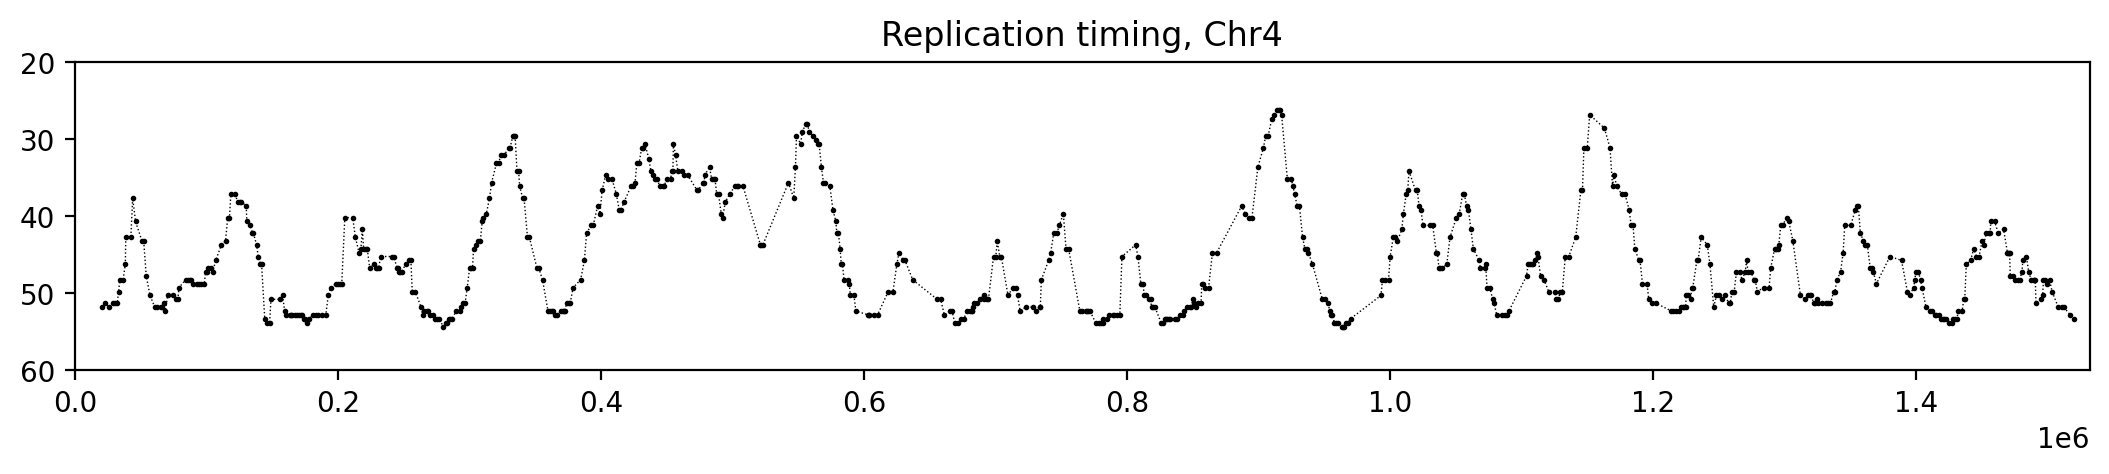

In [6]:
from src.geneset import get_deconvolved_geneset
geneset = get_deconvolved_geneset()

chrom = 4
plot_chrom_repl_timing_from_data(repl_timing, geneset, chrom)

In [7]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.046
1001/5574 - 00:00:05.056
2001/5574 - 00:00:10.100
3001/5574 - 00:00:15.239
4001/5574 - 00:00:20.295
5001/5574 - 00:00:25.411


In [8]:
promoter_analysis.correct_f_images_by_strand()

In [9]:
# Let's get the gene expression at the replication time.

from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()


# Which genes to start with?

Options:

Many genes, all genes compute the chromatin (some delta) before and after replication
- Prior-replication fork
- Post-replication fork

Early vs Late
High vs Low Gene expression


In [10]:
from src.gene_chromatin_replication_analysis import GeneChromatinReplicationAnalysis

gene_chrom_repl_analysis = GeneChromatinReplicationAnalysis(promoter_analysis,
                                                            ge_analysis,
                                                            repl_timing)

5232 genes with replication timing
Shape of the f images:  (5232, 227, 8, 25)


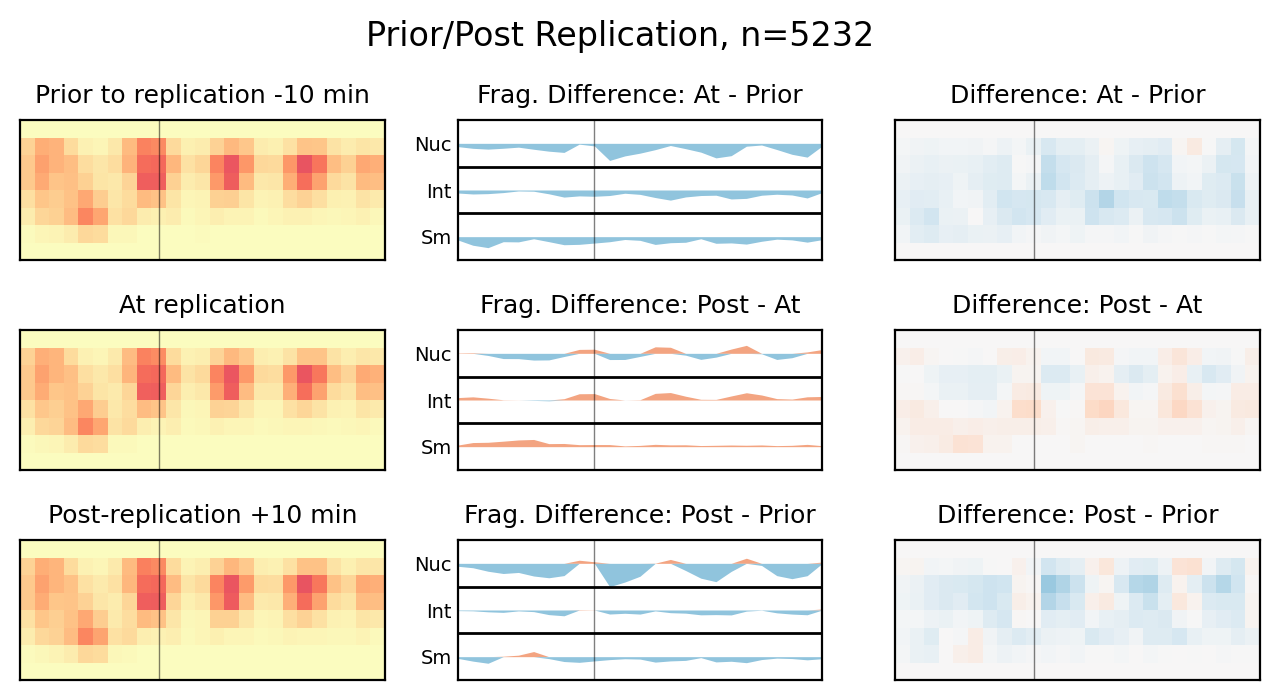

In [11]:
delta_ind = 20

gene_chrom_repl_analysis.select_subset(delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images()

In [12]:
repl_timing_values = gene_chrom_repl_analysis.geneset_repl.replication_timing
repl_timing_values = repl_timing_values.sort_values()

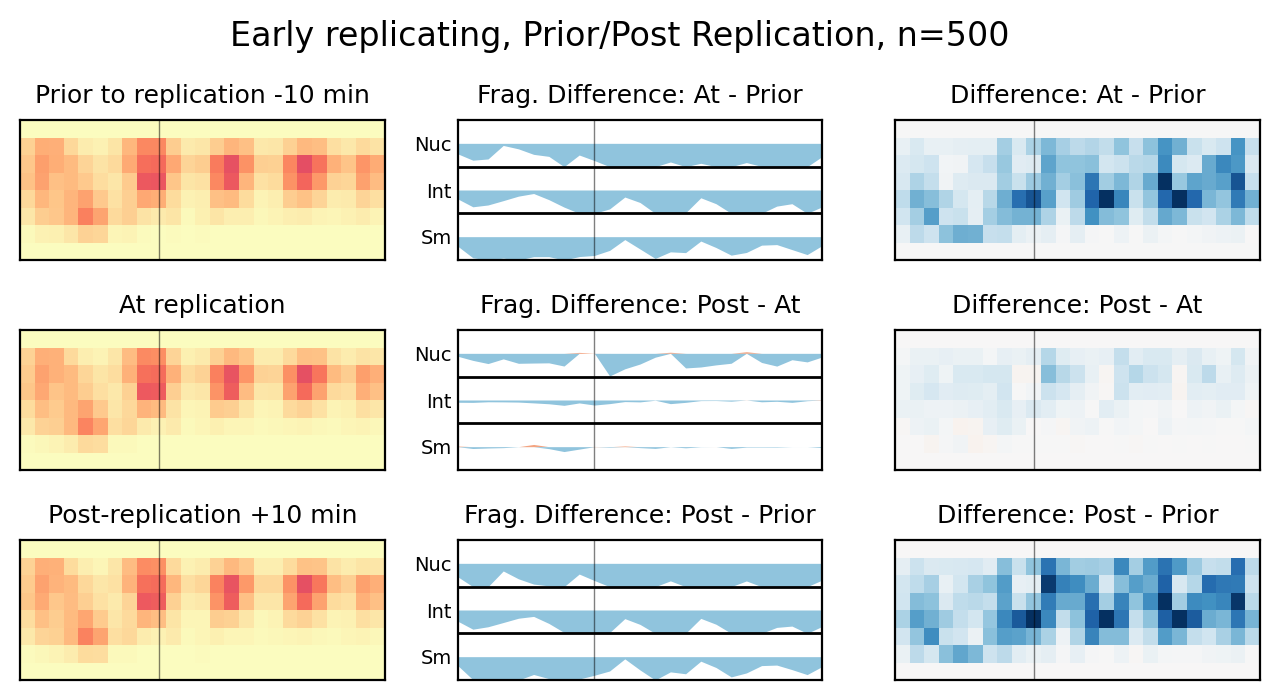

In [13]:
k = 500
gene_chrom_repl_analysis.select_subset(subset_orfs=repl_timing_values.head(k).index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Early replicating")

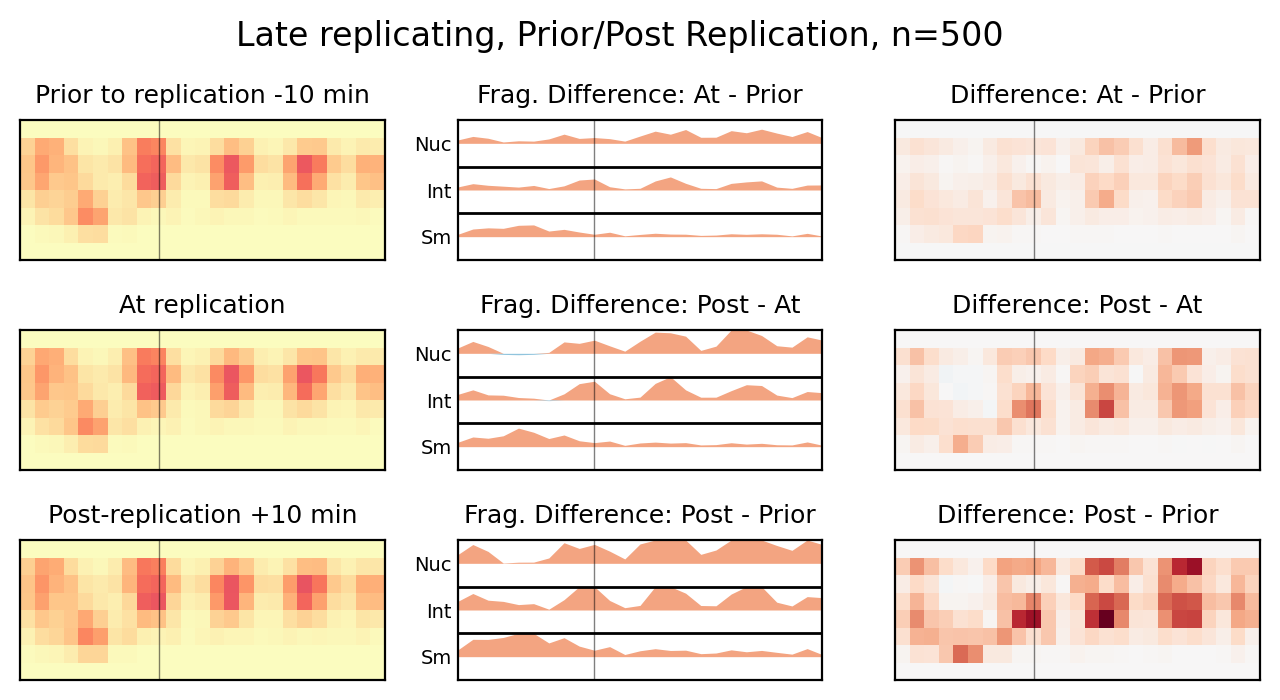

In [14]:
gene_chrom_repl_analysis.select_subset(subset_orfs=repl_timing_values.tail(k).index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Late replicating")

In [15]:
# Analysis of nucleosome entropy wrt to replication timing

In [16]:
from src.helpers import calc_entropy

In [21]:
gene_chrom_repl_analysis.compute_gene_nuc_entropy()

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)


In [34]:
sorted_geneset = gene_chrom_repl_analysis.geneset_repl.sort_values('replication_timing')

NameError: name 'config' is not defined

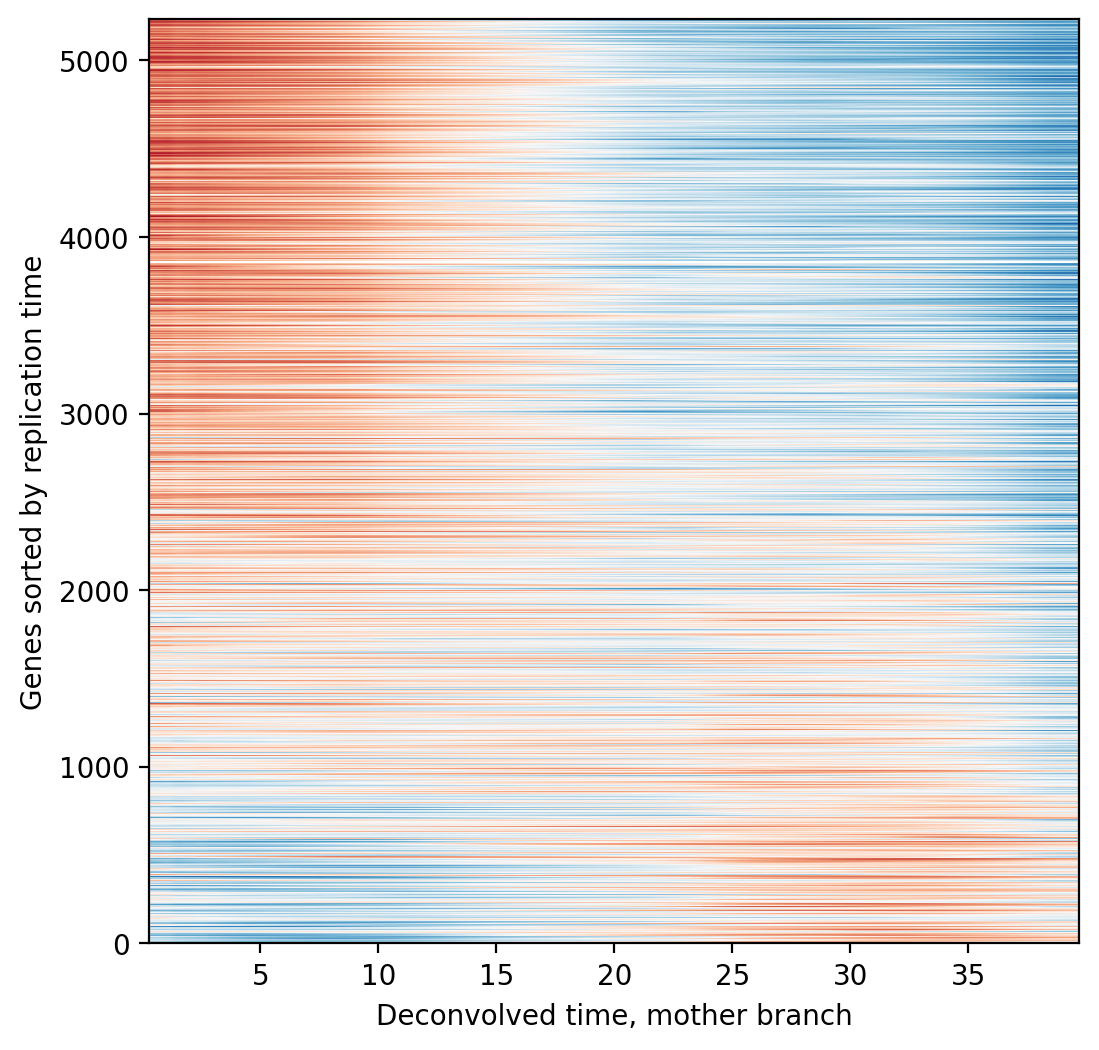

In [43]:
gene_chrom_repl_analysis.plot_entropy_heatmap(sorted_geneset.index, "All genes")